**🦜🔗LangChain is like a giant toolbox + duct tape kit. It gives you abstractions (chains, agents, memory, tools, retrievers, etc.) that you can snap together to make an LLM-powered app. It's very flexible but can get messy—people sometimes say it feels like a jungle gym of components.**

**🔗📊LangGraph is more like a circuit board where you draw out the flow of your app. Instead of chaining functions in a linear sequence, it leans on graph-based workflows. You define nodes (like “call LLM,” “search database,” “filter output”) and edges (the paths between them). It’s built on top of LangChain but brings structure for handling loops, branching, and state management in a cleaner way.**

**LangChain 🛠️ = general-purpose framework to build LLM apps with chains, agents, tools.**

**LangGraph 🔗📊 = built on LangChain, uses graph-based workflows.**

**LangChain ⚡ = super flexible but can get messy for complex apps.**

**LangGraph 🎯 = structured with nodes, edges, loops, branching for cleaner flow.**

### what is AI agent ?
**AI agents are basically LLMs with a brain + arms.**

**The brain 🧠 is the large language model (like GPT), which can understand and generate text.**

**The arms 🤖 are the tools or actions it can take — like searching Google, calling an API, querying a database, or running code.**


In [27]:
def function1(input1):
    return input1   +  " From the first Function"



In [28]:
def function2(input2):
    return input2  +  " charan From the second Function"

In [29]:
def function3(input3):
    pass

In [30]:
function1("Hello AI Learners! ")

'Hello AI Learners!  From the first Function'

In [31]:
function2("Hello Charan! welcome to Langgraph ")

'Hello Charan! welcome to Langgraph  charan From the second Function'

In [32]:
from langgraph.graph import StateGraph, START, END


In [33]:
workflow1 = StateGraph(dict)

In [34]:
workflow1.add_node("fun1",function1)

In [35]:
workflow1.add_node("fun2",function2)

In [36]:
workflow1.add_edge("fun1","fun2")

In [37]:
workflow1.set_entry_point("fun1")

In [38]:
workflow1.set_finish_point("fun2")

In [39]:

app=workflow1.compile()

In [40]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'fun1': Node(id='fun1', name='fun1', data=fun1(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'fun2': Node(id='fun2', name='fun2', data=fun2(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='fun1', data=None, conditional=False), Edge(source='fun1', target='fun2', data=None, conditional=False), Edge(source='fun2', target='__end__', data=None, conditional=False)])

### Displaying Workflow

In [41]:

from IPython.display import Image, display

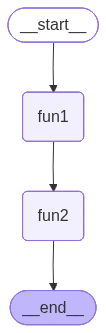

In [42]:
display(Image(app.get_graph().draw_mermaid_png()))

In [43]:
app.invoke("hi iam sai ")

'hi iam sai  From the first Function charan From the second Function'

In [44]:
for output in app.stream("hi this is saicharan"):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

here is output from fun1
_______
hi this is saicharan From the first Function


here is output from fun2
_______
hi this is saicharan From the first Function charan From the second Function




### LLM CALL

In [45]:
import google.generativeai as genai
import os

genai.configure(api_key=os.getenv("GOOGLE_API_KEY"))

for m in genai.list_models():
    if 'generateContent' in m.supported_generation_methods:
        print(m.name)

E0000 00:00:1759751306.222891 3215982 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


models/gemini-2.5-pro-preview-03-25
models/gemini-2.5-flash-preview-05-20
models/gemini-2.5-flash
models/gemini-2.5-flash-lite-preview-06-17
models/gemini-2.5-pro-preview-05-06
models/gemini-2.5-pro-preview-06-05
models/gemini-2.5-pro
models/gemini-2.0-flash-exp
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-exp-image-generation
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.0-flash-preview-image-generation
models/gemini-2.0-flash-lite-preview-02-05
models/gemini-2.0-flash-lite-preview
models/gemini-2.0-pro-exp
models/gemini-2.0-pro-exp-02-05
models/gemini-exp-1206
models/gemini-2.0-flash-thinking-exp-01-21
models/gemini-2.0-flash-thinking-exp
models/gemini-2.0-flash-thinking-exp-1219
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/learnlm-2.0-flash-experimental
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models

In [46]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ['GOOGLE_API_KEY'] = os.getenv("GOOGLE_API_KEY")

In [47]:
from langchain_google_genai import ChatGoogleGenerativeAI
model=ChatGoogleGenerativeAI(model='models/gemini-2.0-flash')

E0000 00:00:1759751307.085458 3215982 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [48]:

model.invoke("hi").content

'Hi there! How can I help you today?'

In [49]:
def llm(input):
    from langchain_google_genai import ChatGoogleGenerativeAI
    model=ChatGoogleGenerativeAI(model='models/gemini-2.0-flash')
    output=model.invoke(input)
    return output.content

In [50]:
def token_counter(input):
    token=input.split()
    token_number=len(token)
    return f"total token number in the generated answer is {token_number}"

In [51]:
from langgraph.graph import StateGraph




In [52]:
workflow2 = StateGraph(dict)

In [53]:
workflow2.add_node("My_LLM",llm)

In [54]:
workflow2.add_node("LLM_Output_Token_Counter",token_counter)

In [55]:

workflow2.add_edge("My_LLM","LLM_Output_Token_Counter")

In [56]:
workflow2.set_entry_point("My_LLM")

In [57]:

workflow2.set_finish_point("LLM_Output_Token_Counter")

In [58]:

app=workflow2.compile()

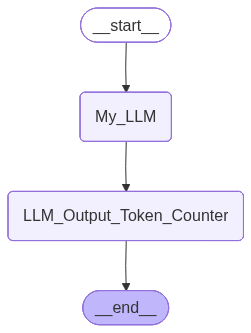

In [59]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [61]:
app.invoke("can you tell me about the india's capital?")

E0000 00:00:1759751318.391203 3215982 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


'total token number in the generated answer is 361'

In [62]:
app.invoke("tell me about the tata enterpirse in very detail.")

E0000 00:00:1759751357.414746 3215982 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


'total token number in the generated answer is 1455'

In [63]:
for output in app.stream("tell me about the tata enterpirse in very detail."):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

E0000 00:00:1759751387.232264 3215982 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


here is output from My_LLM
_______
Okay, let's delve into a detailed overview of the Tata Group, one of India's largest and most respected multinational conglomerates.

**I. Overview**

*   **Name:** Tata Group
*   **Type:** Multinational Conglomerate
*   **Headquarters:** Mumbai, Maharashtra, India
*   **Founded:** 1868 by Jamsetji Tata
*   **Founder:** Jamsetji Tata
*   **Chairman:** N. Chandrasekaran
*   **Ownership:** Primarily Tata Trusts (a philanthropic arm) and Tata Sons (the holding company).
*   **Revenue (FY2023):** $150 Billion
*   **Employees:** Over 1 Million
*   **Presence:** Operates in over 100 countries across six continents.
*   **Sectors:** The Tata Group is involved in a wide array of industries, including:
    *   Information Technology
    *   Steel
    *   Automotive
    *   Consumer and Retail
    *   Infrastructure
    *   Financial Services
    *   Aerospace and Defence
    *   Tourism and Hospitality
    *   Telecommunications
    *   Chemicals

**II. Histor

## google search testing using langchain 

In [73]:
import google.generativeai as genai
import os

genai.configure(api_key=os.getenv("GOOGLE_API_KEY"))

model = genai.GenerativeModel("models/gemini-flash-latest")
response = model.generate_content("What is langchain and langgraph? explain in detail")
print(response.text)

E0000 00:00:1759751807.983284 3215982 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


That's a great question, as LangChain and LangGraph are central to modern AI development, particularly in building complex applications with Large Language Models (LLMs).

Here is a detailed explanation of both frameworks, their goals, and the relationship between them.

---

## 1. What is LangChain?

**LangChain** is a comprehensive framework designed to simplify the creation of complex applications that rely on Large Language Models (LLMs). Its core mission is to help developers **"chain"** together different components—such as LLMs, data sources, APIs, and computation tools—to build sophisticated, data-aware, and agentic applications.

LangChain is less about training the LLM itself and more about **orchestrating** its interaction with the outside world.

### Core Philosophy and Goal

The primary goal of LangChain is to make LLMs **useful** by connecting them to:
1.  **Data:** Allowing models to interact with specific, up-to-date, or private organizational data (e.g., via databases 

In [74]:
app.invoke("Explain the theory of relativity in simple terms.")

E0000 00:00:1759751945.219922 3215982 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


'total token number in the generated answer is 825'